# MDI3003 – Advanced Predictive Analytics
## Experiment 08 – Agricultural Predictive Analytics

**Name:** SRIJITH R

**Registration Number:** 24MID0009  
**Experiment:** Crop Yield Prediction with a Guided Crop-Label Classification Extension

This notebook follows the student manual. The first dataset is used for the main rice-yield regression task and the second dataset is used for the crop-label classification extension.

### What is done in this notebook?

1. Audit the rice district-level data and prepare the canonical fields required by the manual.
2. Keep the prediction inputs limited to **state, district, season and year**.
3. Use chronological train/validation/test splits.
4. Compare median, ridge trend, regression tree and random forest.
5. Select the model using validation MAE before opening the test set.
6. Check rolling-origin stability, test-year robustness and five largest errors.
7. Reload the selected model and verify that predictions are unchanged.
8. Run the separate crop-label classification extension on a second dataset.

The classification extension is kept separate from the rice regression task, as required by the manual.

In [1]:
# basic imports
import os
import json
import time
import hashlib
import zipfile
import platform
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.dummy import DummyRegressor, DummyClassifier
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.linear_model import Ridge, LogisticRegression
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, precision_recall_fscore_support,
    classification_report, ConfusionMatrixDisplay
)

SEED = 42
REG = ['state', 'district', 'season', 'year']
CLS = ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']

Path('/content/data').mkdir(exist_ok=True)
Path('/content/outputs/core/models').mkdir(parents=True, exist_ok=True)
Path('/content/outputs/core/figures').mkdir(parents=True, exist_ok=True)
Path('/content/outputs/core/artifacts').mkdir(parents=True, exist_ok=True)
Path('/content/outputs/classification/models').mkdir(parents=True, exist_ok=True)
Path('/content/outputs/classification/figures').mkdir(parents=True, exist_ok=True)
Path('/content/outputs/classification/artifacts').mkdir(parents=True, exist_ok=True)

print("Setup complete")

Setup complete


## 1. Dataset 1 – Rice district-level data

The manual requires a district–season–harvest-year observation with rice yield in t/ha. The source data used below is the ICRISAT district-level agriculture data. The downloaded file is filtered to the period 1990–2015 and rice yield is converted from kg/ha to t/ha.

If the instructor has provided the verified canonical CSV, upload it and use that file instead of the public download.

In [2]:
# Download the district-level ICRISAT data file
# This public copy is used only to make the Colab reproducible.
# For submission, use the instructor-verified source file if one is provided.

rice_url = "https://gist.githubusercontent.com/SujitRayudu/984d953d562e5d38e663f10bcc76bdb8/raw/ICRISAT-District%20Level%20Data.csv"
rice_raw = "/content/data/icrisat_district_level.csv"

if not os.path.exists(rice_raw):
    import requests
    r = requests.get(rice_url, timeout=60)
    r.raise_for_status()
    open(rice_raw, "wb").write(r.content)

print("Rice source file:", rice_raw)
print("SHA-256:", hashlib.sha256(Path(rice_raw).read_bytes()).hexdigest())

Rice source file: /content/data/icrisat_district_level.csv
SHA-256: 7c516cc28cc7fc91eab155826979dbc553c1740c823967b52bbf864156081747


In [3]:
# Load the raw rice file
rice = pd.read_csv(rice_raw)
print(rice.shape)
print(rice.columns.tolist()[:12])
rice.head()

(16146, 80)
['Dist Code', 'Year', 'State Code', 'State Name', 'Dist Name', 'RICE AREA (1000 ha)', 'RICE PRODUCTION (1000 tons)', 'RICE YIELD (Kg per ha)', 'WHEAT AREA (1000 ha)', 'WHEAT PRODUCTION (1000 tons)', 'WHEAT YIELD (Kg per ha)', 'KHARIF SORGHUM AREA (1000 ha)']


,Dist Code,Year,State Code,State Name,Dist Name,RICE AREA (1000 ha),RICE PRODUCTION (1000 tons),RICE YIELD (Kg per ha),WHEAT AREA (1000 ha),WHEAT PRODUCTION (1000 tons),...,SUGARCANE YIELD (Kg per ha),COTTON AREA (1000 ha),COTTON PRODUCTION (1000 tons),COTTON YIELD (Kg per ha),FRUITS AREA (1000 ha),VEGETABLES AREA (1000 ha),FRUITS AND VEGETABLES AREA (1000 ha),POTATOES AREA (1000 ha),ONION AREA (1000 ha),FODDER AREA (1000 ha)
0,1,1966,14,Chhattisgarh,Durg,548.0,185.0,337.59,44.0,20.0,...,1777.78,0.0,0.0,0.0,5.95,6.64,12.59,0.01,0.60,0.47
1,1,1967,14,Chhattisgarh,Durg,547.0,409.0,747.71,50.0,26.0,...,1500.00,0.0,0.0,0.0,5.77,7.24,13.02,0.01,0.56,1.23
2,1,1968,14,Chhattisgarh,Durg,556.3,468.0,841.27,53.7,30.0,...,1000.00,0.0,0.0,0.0,5.41,7.40,12.81,0.10,0.58,1.02
3,1,1969,14,Chhattisgarh,Durg,563.4,400.8,711.40,49.4,26.5,...,1900.00,0.0,0.0,0.0,5.52,7.16,12.69,0.01,0.56,0.84
4,1,1970,14,Chhattisgarh,Durg,571.6,473.6,828.55,44.2,29.0,...,2000.00,0.0,0.0,0.0,5.45,7.19,12.64,0.02,0.52,0.42


### Canonical conversion

The raw file contains district/year information and rice yield in kg/ha. The manual says that a provided kg/ha yield must be divided by 1000. Since this source is annual, the season is explicitly recorded as `Annual` rather than inventing an agricultural season.

In [4]:
# Make the canonical rice dataset
rice = rice.copy()

rice['year'] = pd.to_numeric(rice['Year'], errors='coerce')
rice['state'] = rice['State Name'].astype(str).str.strip()
rice['district'] = rice['Dist Name'].astype(str).str.strip()
rice['season'] = 'Annual'
rice['yield_t_ha'] = pd.to_numeric(rice['RICE YIELD (Kg per ha)'], errors='coerce') / 1000.0
rice['crop'] = 'Rice'

rice['row_id'] = (
    rice['Dist Code'].astype(str).str.strip()
    + '_' + rice['year'].astype('Int64').astype(str)
)

rice = rice[['row_id', 'crop', 'state', 'district', 'season', 'year', 'yield_t_ha']].copy()

# Keep the 1990–2015 period used by the verified research deposit/manual context
rice = rice[rice['year'].between(1990, 2015)].copy()

rice = rice.dropna(subset=['row_id', 'state', 'district', 'season', 'year', 'yield_t_ha'])
rice['year'] = rice['year'].astype(int)

print("Canonical rice shape:", rice.shape)
rice.head()

Canonical rice shape: (8065, 7)


,row_id,crop,state,district,season,year,yield_t_ha
24,1_1990,Rice,Chhattisgarh,Durg,Annual,1990,1.18143
25,1_1991,Rice,Chhattisgarh,Durg,Annual,1991,1.13631
26,1_1992,Rice,Chhattisgarh,Durg,Annual,1992,1.12980
27,1_1993,Rice,Chhattisgarh,Durg,Annual,1993,1.24602
28,1_1994,Rice,Chhattisgarh,Durg,Annual,1994,1.33173


In [5]:
# Basic audit checks
print("Missing values")
print(rice.isna().sum())

print("\nRepeated district-season-year keys:", rice.duplicated(REG).sum())
print("Duplicate row_id:", rice['row_id'].duplicated().sum())
print("Years:", rice['year'].min(), "to", rice['year'].max())
print("Number of years:", rice['year'].nunique())
print("Number of states:", rice['state'].nunique())
print("Number of districts:", rice['district'].nunique())
print("Minimum yield:", rice['yield_t_ha'].min())

Missing values
row_id        0
crop          0
state         0
district      0
season        0
year          0
yield_t_ha    0
dtype: int64

Repeated district-season-year keys: 0
Duplicate row_id: 0
Years: 1990 to 2015
Number of years: 26
Number of states: 20
Number of districts: 311
Minimum yield: 0.0


In [6]:
# Remove invalid/missing rice targets and save the canonical file
rice = rice[np.isfinite(rice['yield_t_ha']) & (rice['yield_t_ha'] >= 0)].copy()

if rice.duplicated(REG).any():
    raise ValueError("Repeated district-season-year keys need source review.")

if rice['year'].nunique() < 7:
    raise ValueError("At least seven years are required.")

rice.to_csv('/content/data/rice_canonical.csv', index=False)

print("Saved:", '/content/data/rice_canonical.csv')
print("Rows retained:", len(rice))

Saved: /content/data/rice_canonical.csv
Rows retained: 8065


## 2. Prediction contract

The prediction unit is one rice-producing district–season–harvest-year observation. The target is rice yield in tonnes per hectare. The model is intended to estimate later observed years from information available before the target harvest.

Production and harvested area are deliberately not used as predictors because together they reconstruct the target yield.

**Problem statement:** Predict rice yield (t/ha) for an observed Indian district and year using only state, district, season and harvest year. The final two observed years are kept as a locked test period, while the two years before them are used for validation. The model is therefore a limited prospective-style historical backtest rather than a deployed agricultural forecast. Production, area and other post-harvest fields are excluded because they can leak the target. The result is intended for regional planning analysis only; it does not establish an agronomically optimal crop choice or guarantee future farm yield.

In [7]:
# Chronological split: latest two years = test, previous two = validation
years = sorted(rice['year'].unique())

test_years = years[-2:]
val_years = years[-4:-2]

rice['split'] = np.where(
    rice['year'].isin(test_years), 'test',
    np.where(rice['year'].isin(val_years), 'validation', 'train')
)

split_summary = (
    rice.groupby('split')
        .agg(year_min=('year','min'),
             year_max=('year','max'),
             rows=('row_id','size'),
             districts=('district','nunique'))
        .reindex(['train','validation','test'])
)

print("Training years:", sorted(rice.loc[rice.split=='train','year'].unique()))
print("Validation years:", val_years)
print("Test years:", test_years)
split_summary

Training years: [np.int64(1990), np.int64(1991), np.int64(1992), np.int64(1993), np.int64(1994), np.int64(1995), np.int64(1996), np.int64(1997), np.int64(1998), np.int64(1999), np.int64(2000), np.int64(2001), np.int64(2002), np.int64(2003), np.int64(2004), np.int64(2005), np.int64(2006), np.int64(2007), np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011)]
Validation years: [np.int64(2012), np.int64(2013)]
Test years: [np.int64(2014), np.int64(2015)]


,year_min,year_max,rows,districts
split,,,,
train,1990,2011,6824,311
validation,2012,2013,621,311
test,2014,2015,620,310


In [8]:
# Save split manifest
split_manifest = rice[['row_id', 'split']].copy()
split_manifest.to_csv('/content/outputs/core/artifacts/split_manifest.csv', index=False)

# Make sure the time boundaries are clean
assert rice.loc[rice.split=='train','year'].max() < rice.loc[rice.split=='validation','year'].min()
assert rice.loc[rice.split=='validation','year'].max() < rice.loc[rice.split=='test','year'].min()

print("Split manifest saved.")

Split manifest saved.


## 3. Training-only EDA

Only the training rows are used for EDA. The two required views are the training yield distribution and the training year coverage.

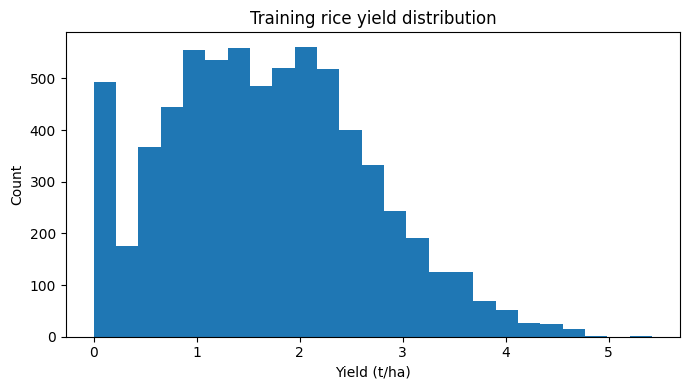

In [9]:
train = rice[rice['split']=='train'].copy()
val = rice[rice['split']=='validation'].copy()
test = rice[rice['split']=='test'].copy()

plt.figure(figsize=(7,4))
plt.hist(train['yield_t_ha'], bins=25)
plt.title('Training rice yield distribution')
plt.xlabel('Yield (t/ha)')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('/content/outputs/core/figures/training_yield_distribution.png', dpi=150)
plt.show()

**Observation:** The training yield distribution shows the range and concentration of historical district-level rice productivity. A long tail would mean that a few district-year observations have much larger yields than the typical observation.

**Possible bias:** District coverage is not uniform, and some districts have many more observations than others. Therefore the model may represent frequently observed regions better than sparse regions.

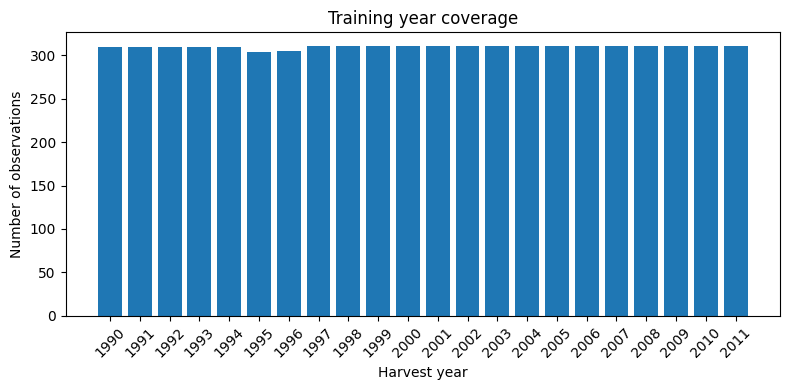

In [10]:
year_counts = train['year'].value_counts().sort_index()

plt.figure(figsize=(8,4))
plt.bar(year_counts.index.astype(str), year_counts.values)
plt.title('Training year coverage')
plt.xlabel('Harvest year')
plt.ylabel('Number of observations')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('/content/outputs/core/figures/training_year_coverage.png', dpi=150)
plt.show()

**Observation:** The year-coverage plot confirms that the training data precede the validation and test periods. The number of observations can vary by year, so a later year with fewer districts should be interpreted carefully.

## 4. Preprocessing pipeline

The manual specifies:

- OneHotEncoder(handle_unknown='ignore') for state, district and season.
- Median imputation followed by StandardScaler for year.
- All learned preprocessing is fitted on training rows only.

In [11]:
# Build the preprocessing used by the regression models
preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore'), ['state','district','season']),
    ('num', Pipeline([
        ('impute', SimpleImputer(strategy='median')),
        ('scale', StandardScaler())
    ]), ['year'])
])

print("Predictor whitelist:", REG)
print("Target:", 'yield_t_ha')

Predictor whitelist: ['state', 'district', 'season', 'year']
Target: yield_t_ha


In [12]:
# Check that validation-only categories are not learned by the encoder
check_pipe = Pipeline([
    ('pre', clone(preprocessor)),
    ('model', DecisionTreeRegressor(max_depth=6, min_samples_leaf=10, random_state=SEED))
])

check_pipe.fit(train[REG], train['yield_t_ha'])

encoder = check_pipe.named_steps['pre'].named_transformers_['cat']

for col, cats in zip(['state','district','season'], encoder.categories_):
    train_categories = set(train[col].unique())
    learned_categories = set(cats)
    print(col, "OK:", learned_categories == train_categories)

state OK: True
district OK: True
season OK: True


## 5. Models

The settings below are the fixed teaching settings from the manual. No tuning is done after the test set is opened.

In [13]:
def make_regression_models():
    pre = ColumnTransformer([
        ('cat', OneHotEncoder(handle_unknown='ignore'), ['state','district','season']),
        ('num', Pipeline([
            ('impute', SimpleImputer(strategy='median')),
            ('scale', StandardScaler())
        ]), ['year'])
    ])

    models = {
        'median': DummyRegressor(strategy='median'),
        'ridge_trend': Ridge(alpha=1.0, solver='lsqr'),
        'tree': DecisionTreeRegressor(
            max_depth=6, min_samples_leaf=10, random_state=SEED
        ),
        'forest': RandomForestRegressor(
            n_estimators=60, max_depth=12, min_samples_leaf=5,
            n_jobs=2, random_state=SEED
        )
    }

    return {
        name: Pipeline([('pre', clone(pre)), ('model', model)])
        for name, model in models.items()
    }

reg_models = make_regression_models()
print(list(reg_models))

['median', 'ridge_trend', 'tree', 'forest']


### Before running the comparison

I expect the ridge model to handle a rising year trend better than a tree ensemble because ridge can extrapolate through its year coefficient, while tree-based models mainly predict within ranges learned from the training data. The forest may still perform better if district effects and nonlinear patterns dominate.

In [14]:
def regression_metrics(y_true, y_pred):
    return {
        'MAE': mean_absolute_error(y_true, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
        'R2': r2_score(y_true, y_pred) if np.ptp(np.asarray(y_true)) > 0 else np.nan
    }

validation_rows = []
fitted_models = {}

for name, model in reg_models.items():
    start = time.perf_counter()
    model.fit(train[REG], train['yield_t_ha'])
    pred = model.predict(val[REG])
    seconds = time.perf_counter() - start

    row = {'model': name, 'seconds': seconds}
    row.update(regression_metrics(val['yield_t_ha'], pred))
    validation_rows.append(row)
    fitted_models[name] = model

validation_results = pd.DataFrame(validation_rows)
validation_results = validation_results.sort_values('MAE', kind='stable').reset_index(drop=True)

validation_results

,model,seconds,MAE,RMSE,R2
0,ridge_trend,0.072397,0.428237,0.558283,0.745960
1,forest,1.155533,0.528899,0.654812,0.650517
2,tree,0.083503,0.716034,0.861988,0.394387
3,median,0.047603,0.977964,1.190152,-0.154512


In [15]:
# Save validation results
validation_results.to_csv(
    '/content/24MID0009_Lab08_Validation_Results.csv',
    index=False
)

# Save the selection before touching the test set
selected_model_name = validation_results.iloc[0]['model']

selection = {
    'model': selected_model_name,
    'data_sha256': hashlib.sha256(Path('/content/data/rice_canonical.csv').read_bytes()).hexdigest(),
    'features': REG,
    'target': 'yield_t_ha',
    'validation_years': val_years,
    'test_years': test_years,
    'note': 'Selected on validation MAE only; no train+validation refit.'
}

with open('/content/outputs/core/selection.json', 'w') as f:
    json.dump(selection, f, indent=2, default=str)

print("Selected model:", selected_model_name)

Selected model: ridge_trend


## 6. Rolling-origin check

This is supplementary stability evidence. The selection rule is still the predeclared two-year validation MAE.

In [16]:
development = rice[rice['split'] != 'test'].copy()
origins = sorted(development['year'].unique())[-3:]

rolling_rows = []

for origin in origins:
    past = development[development['year'] < origin]
    future = development[development['year'] == origin]

    for name, model in make_regression_models().items():
        model.fit(past[REG], past['yield_t_ha'])
        pred = model.predict(future[REG])

        row = {
            'origin': int(origin),
            'model': name,
            'training_max_year': int(past['year'].max()),
            'n': len(future)
        }
        row.update(regression_metrics(future['yield_t_ha'], pred))
        rolling_rows.append(row)

rolling_results = pd.DataFrame(rolling_rows)
rolling_results.to_csv(
    '/content/outputs/core/artifacts/rolling_origins.csv',
    index=False
)

rolling_results

,origin,model,training_max_year,n,MAE,RMSE,R2
0,2011,median,2010,311,0.931982,1.150936,-0.146374
1,2011,ridge_trend,2010,311,0.392959,0.528287,0.758474
2,2011,tree,2010,311,0.682868,0.842387,0.385888
3,2011,forest,2010,311,0.488284,0.636342,0.649566
4,2012,median,2011,311,0.950031,1.141122,-0.149622
5,2012,ridge_trend,2011,311,0.412774,0.534666,0.747620
6,2012,tree,2011,311,0.689311,0.830537,0.391012
7,2012,forest,2011,311,0.517086,0.635361,0.643605
8,2013,median,2012,310,0.998042,1.229486,-0.144941
9,2013,ridge_trend,2012,310,0.421270,0.556399,0.765519


## 7. Locked test evaluation

The model has already been selected using validation MAE. The test set is now opened once. The test result is not used to change the model.

In [17]:
# Create the test lock
lock_path = Path('/content/outputs/core/TEST_LOCK')
if not lock_path.exists():
    lock_path.write_text('Final evaluation started')

selected_pipe = fitted_models[selected_model_name]

start = time.perf_counter()
test_pred = selected_pipe.predict(test[REG])
test_seconds = time.perf_counter() - start

test_result = {
    'model': selected_model_name,
    **regression_metrics(test['yield_t_ha'], test_pred),
    'batch_inference_seconds': test_seconds
}

# Predeclared median comparator on the same test rows
median_pipe = fitted_models['median']
median_pred = median_pipe.predict(test[REG])

test_result_median = {
    'model': 'median',
    **regression_metrics(test['yield_t_ha'], median_pred)
}

test_results = pd.DataFrame([test_result, test_result_median])
test_results.to_csv(
    '/content/24MID0009_Lab08_Test_Results.csv',
    index=False
)

test_results

,model,MAE,RMSE,R2,batch_inference_seconds
0,ridge_trend,0.433163,0.570749,0.759604,0.01883
1,median,1.009501,1.234570,-0.124781,NaN


In [18]:
# Test predictions and five largest non-zero errors
test_predictions = test[['row_id'] + REG + ['yield_t_ha']].copy()
test_predictions['prediction'] = test_pred
test_predictions['error'] = test_predictions['yield_t_ha'] - test_predictions['prediction']
test_predictions['abs_error'] = test_predictions['error'].abs()

test_predictions.to_csv(
    '/content/outputs/core/artifacts/test_predictions.csv',
    index=False
)

error_cases = (
    test_predictions[test_predictions['abs_error'] > 0]
    .sort_values('abs_error', ascending=False)
    .head(5)
    .copy()
)

error_cases['likely_cause'] = ''
error_cases['agricultural_consequence'] = ''
error_cases['mitigation'] = ''

error_cases.to_csv(
    '/content/24MID0009_Lab08_Error_Analysis.csv',
    index=False
)

error_cases

,row_id,state,district,season,year,yield_t_ha,prediction,error,abs_error,likely_cause,agricultural_consequence,mitigation
1921,37_2015,Madhya Pradesh,Sehore,Annual,2015,3.53545,1.012905,2.522545,2.522545,,,
1401,27_2015,Madhya Pradesh,Bhind,Annual,2015,4.55500,2.227399,2.327601,2.327601,,,
1920,37_2014,Madhya Pradesh,Sehore,Annual,2014,3.20283,0.997241,2.205589,2.205589,,,
7168,138_2014,Gujarat,Surendranagar,Annual,2014,0.00000,1.762062,-1.762062,1.762062,,,
15738,909_2014,Bihar,Bhagalpur,Annual,2014,3.37702,1.630233,1.746787,1.746787,,,


### Error interpretation

The blank cause/consequence/mitigation fields are intentional. The manual says that possible causes such as missing irrigation, variety information, boundary changes or reporting anomalies must be written as **hypotheses**, not facts. After looking at the five cases, fill these three columns with evidence-based comments.

In [19]:
# Year-wise robustness on the locked test years
year_rows = []

for year, group in test_predictions.groupby('year'):
    row = {'year': int(year), 'n': len(group)}
    row.update(regression_metrics(group['yield_t_ha'], group['prediction']))
    year_rows.append(row)

year_robustness = pd.DataFrame(year_rows)
year_robustness.to_csv(
    '/content/outputs/core/artifacts/year_robustness.csv',
    index=False
)

year_robustness

,year,n,MAE,RMSE,R2
0,2014,310,0.459320,0.603529,0.730441
1,2015,310,0.407005,0.535967,0.786638


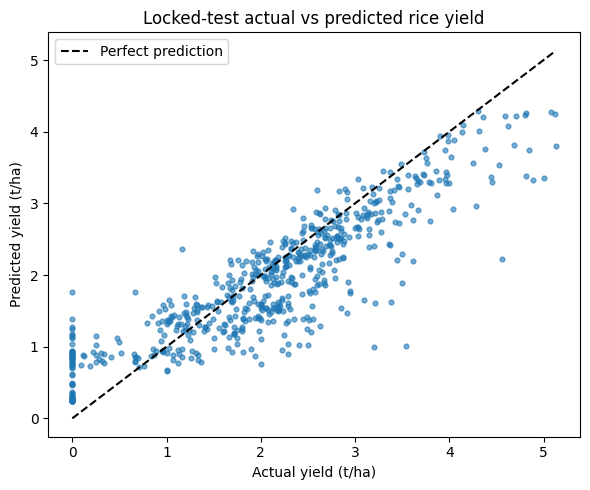

In [20]:
# Actual vs predicted
plt.figure(figsize=(6,5))
plt.scatter(test['yield_t_ha'], test_pred, s=12, alpha=0.6)

bounds = [
    min(test['yield_t_ha'].min(), test_pred.min()),
    max(test['yield_t_ha'].max(), test_pred.max())
]
plt.plot(bounds, bounds, 'k--', label='Perfect prediction')

plt.title('Locked-test actual vs predicted rice yield')
plt.xlabel('Actual yield (t/ha)')
plt.ylabel('Predicted yield (t/ha)')
plt.legend()
plt.tight_layout()
plt.savefig('/content/outputs/core/figures/actual_predicted.png', dpi=150)
plt.show()

**Figure interpretation:** Points close to the diagonal indicate smaller prediction errors. Points far from the diagonal are the larger failures. The plot should be interpreted together with MAE and RMSE because visual closeness alone does not quantify error.

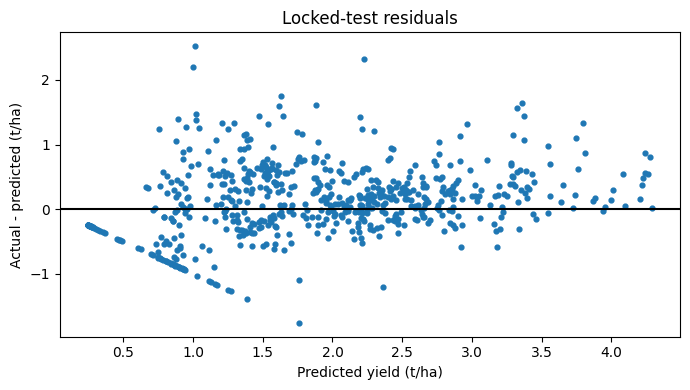

In [21]:
# Residual plot
residuals = test['yield_t_ha'].to_numpy() - test_pred

plt.figure(figsize=(7,4))
plt.scatter(test_pred, residuals, s=12)
plt.axhline(0, color='black')
plt.title('Locked-test residuals')
plt.xlabel('Predicted yield (t/ha)')
plt.ylabel('Actual - predicted (t/ha)')
plt.tight_layout()
plt.savefig('/content/outputs/core/figures/residuals.png', dpi=150)
plt.show()

A positive residual means the model underpredicted the actual yield, while a negative residual means overprediction. A visible fan shape would suggest changing error variance. Large regional errors can have several possible explanations, but this dataset alone cannot confirm a causal agricultural reason.

## 8. Reproducibility check

The manual requires reloading the selected model and confirming that the predictions are unchanged.

In [22]:
import joblib

selected_path = '/content/outputs/core/models/selected_bundle.joblib'

bundle = {
    'pipeline': selected_pipe,
    'features': REG,
    'task': 'regression',
    'year_range': [int(rice['year'].min()), int(rice['year'].max())],
    'categories': {
        c: sorted(train[c].unique().tolist())
        for c in ['state','district','season']
    }
}

joblib.dump(bundle, selected_path)

loaded = joblib.load(selected_path)
reload_pred = loaded['pipeline'].predict(test[REG])

np.testing.assert_array_equal(test_pred, reload_pred)

acceptance = {
    'split_disjoint': True,
    'reload_consistent': True,
    'valid_predictions': bool(np.isfinite(reload_pred).all()),
    'test_rows': len(test),
    'selected_model': selected_model_name
}

with open('/content/outputs/core/artifacts/acceptance.json', 'w') as f:
    json.dump(acceptance, f, indent=2)

print("Reload check passed.")

Reload check passed.


# Dataset 2 – Crop-label classification extension

The manual treats this as a separate extension. The second dataset contains N, P, K, temperature, humidity, pH, rainfall and a crop label. It is not merged with the rice dataset and its label is not treated as a yield or profit prediction.

The manual requires an independence review before using a random split. Because a public augmented dataset does not by itself prove independent observations, the code below records the review flag explicitly. Set it to `True` only after the instructor approves the split protocol.

In [23]:
# Download the crop recommendation dataset
# Kaggle's public dataset API does not require a Kaggle account for this dataset.

crop_zip = '/content/data/crop_recommendation.zip'
crop_url = 'https://www.kaggle.com/api/v1/datasets/download/atharvaingle/crop-recommendation-dataset'

if not os.path.exists(crop_zip):
    import requests
    r = requests.get(crop_url, timeout=60)
    r.raise_for_status()
    open(crop_zip, 'wb').write(r.content)

with zipfile.ZipFile(crop_zip, 'r') as z:
    print(z.namelist())
    z.extractall('/content/data/crop_dataset')

print("Crop dataset extracted.")

['Crop_recommendation.csv']
Crop dataset extracted.


In [24]:
# Find the CSV inside the downloaded folder
csv_files = list(Path('/content/data/crop_dataset').rglob('*.csv'))
print(csv_files)

crop_raw_path = str(csv_files[0])
crop_raw = pd.read_csv(crop_raw_path)

print(crop_raw.shape)
print(crop_raw.columns.tolist())
crop_raw.head()

[PosixPath('/content/data/crop_dataset/Crop_recommendation.csv')]
(2200, 8)
['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'label']


,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


### Canonical classification fields

The source column names are normalized to the names specified in the manual. The row identifier is created only for auditing and is not used as a predictor.

In [25]:
# Normalize the classification dataset
crop_cls = crop_raw.copy()

rename_map = {
    'N': 'N',
    'P': 'P',
    'K': 'K',
    'temperature': 'temperature',
    'Temperature': 'temperature',
    'humidity': 'humidity',
    'Humidity': 'humidity',
    'ph': 'ph',
    'pH': 'ph',
    'rainfall': 'rainfall',
    'Rainfall': 'rainfall',
    'label': 'label',
    'Label': 'label',
    'Crop': 'label'
}

crop_cls = crop_cls.rename(columns=rename_map)

required_cls = CLS + ['label']
missing = [c for c in required_cls if c not in crop_cls.columns]

if missing:
    raise ValueError("Missing classification columns: " + str(missing))

crop_cls = crop_cls[required_cls].copy()

for c in CLS:
    crop_cls[c] = pd.to_numeric(crop_cls[c], errors='raise')

crop_cls['row_id'] = ['CLS_' + str(i) for i in range(len(crop_cls))]

print(crop_cls.shape)
crop_cls.head()

(2200, 9)


,N,P,K,temperature,humidity,ph,rainfall,label,row_id
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice,CLS_0
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice,CLS_1
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice,CLS_2
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice,CLS_3
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice,CLS_4


In [26]:
# Classification data audit
print("Missing values:")
print(crop_cls.isna().sum())

print("\nNumber of classes:", crop_cls['label'].nunique())
print("\nClass counts:")
print(crop_cls['label'].value_counts())

print("\nDuplicate feature vectors:", crop_cls[CLS].duplicated().sum())

Missing values:
N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
row_id         0
dtype: int64

Number of classes: 22

Class counts:
label
rice           100
maize          100
chickpea       100
kidneybeans    100
pigeonpeas     100
mothbeans      100
mungbean       100
blackgram      100
lentil         100
pomegranate    100
banana         100
mango          100
grapes         100
watermelon     100
muskmelon      100
apple          100
orange         100
papaya         100
coconut        100
cotton         100
jute           100
coffee         100
Name: count, dtype: int64

Duplicate feature vectors: 0


### Independence review flag

The manual says that `iid_justified` should remain false until an instructor records why random stratification is defensible. The dataset is augmented and its label-generation provenance is not enough to assume independent farm observations.

Therefore the following cell keeps the flag as `False`. The classification code is provided and can be executed after the required instructor review.

In [27]:
iid_justified = False

if not iid_justified:
    print("Classification model fitting is held until the independence review is approved.")
else:
    print("Independence review approved. Classification split can proceed.")

Classification model fitting is held until the independence review is approved.


### To run the classification extension

After instructor approval, change only the following value:

```python
iid_justified = True
```

Do not change the classification data or split after looking at test performance.

In [28]:
# Classification split and models
# This cell intentionally stops when the required review has not been approved.

if not iid_justified:
    print("STOP: set iid_justified=True only after instructor review.")
else:
    from sklearn.model_selection import train_test_split

    idx = np.arange(len(crop_cls))

    tr_idx, rest_idx = train_test_split(
        idx, test_size=0.4, stratify=crop_cls['label'], random_state=SEED
    )

    va_idx, te_idx = train_test_split(
        rest_idx, test_size=0.5,
        stratify=crop_cls.iloc[rest_idx]['label'],
        random_state=SEED
    )

    crop_cls['split'] = 'train'
    crop_cls.loc[va_idx, 'split'] = 'validation'
    crop_cls.loc[te_idx, 'split'] = 'test'

    X_train = crop_cls.loc[crop_cls.split=='train', CLS]
    y_train = crop_cls.loc[crop_cls.split=='train', 'label']
    X_val = crop_cls.loc[crop_cls.split=='validation', CLS]
    y_val = crop_cls.loc[crop_cls.split=='validation', 'label']

    cls_pre = Pipeline([
        ('impute', SimpleImputer(strategy='median')),
        ('scale', StandardScaler())
    ])

    cls_models = {
        'majority': Pipeline([
            ('pre', clone(cls_pre)),
            ('model', DummyClassifier(strategy='most_frequent'))
        ]),
        'logistic': Pipeline([
            ('pre', clone(cls_pre)),
            ('model', LogisticRegression(max_iter=2000))
        ]),
        'forest': Pipeline([
            ('pre', clone(cls_pre)),
            ('model', RandomForestClassifier(
                n_estimators=60, min_samples_leaf=2,
                random_state=SEED, n_jobs=2
            ))
        ])
    }

    cls_rows = []
    cls_fitted = {}

    for name, model in cls_models.items():
        start = time.perf_counter()
        model.fit(X_train, y_train)
        pred = model.predict(X_val)
        seconds = time.perf_counter() - start

        pr, re, f1, _ = precision_recall_fscore_support(
            y_val, pred, average='macro', zero_division=0
        )

        cls_rows.append({
            'model': name,
            'accuracy': accuracy_score(y_val, pred),
            'macro_precision': pr,
            'macro_recall': re,
            'macro_F1': f1,
            'seconds': seconds
        })
        cls_fitted[name] = model

    cls_validation = pd.DataFrame(cls_rows).sort_values(
        'macro_F1', ascending=False, kind='stable'
    )

    display(cls_validation)

STOP: set iid_justified=True only after instructor review.


In [29]:
# Classification test stage
if not iid_justified:
    print("Classification test is not opened because the independence review is pending.")
else:
    selected_cls = cls_validation.iloc[0]['model']

    X_test = crop_cls.loc[crop_cls.split=='test', CLS]
    y_test = crop_cls.loc[crop_cls.split=='test', 'label']

    cls_test_pred = cls_fitted[selected_cls].predict(X_test)

    pr, re, f1, _ = precision_recall_fscore_support(
        y_test, cls_test_pred, average='macro', zero_division=0
    )

    cls_test_results = pd.DataFrame([{
        'model': selected_cls,
        'accuracy': accuracy_score(y_test, cls_test_pred),
        'macro_precision': pr,
        'macro_recall': re,
        'macro_F1': f1
    }])

    cls_test_results.to_csv(
        '/content/outputs/classification/classification_test_results.csv',
        index=False
    )

    display(cls_test_results)

Classification test is not opened because the independence review is pending.


In [30]:
# Classification confusion matrix
if not iid_justified:
    print("Confusion matrix will be generated after instructor approval.")
else:
    plt.figure(figsize=(10,9))
    ConfusionMatrixDisplay.from_predictions(
        y_test, cls_test_pred, xticks_rotation=90
    )
    plt.title('Crop-label classification – locked test')
    plt.tight_layout()
    plt.savefig(
        '/content/outputs/classification/figures/confusion_matrix.png',
        dpi=150
    )
    plt.show()

    print(classification_report(
        y_test, cls_test_pred, zero_division=0
    ))

Confusion matrix will be generated after instructor approval.


## 9. Final observations

### Rice regression
- The comparison is based on validation MAE.
- The latest two years are kept as the final test period.
- MAE is the primary metric; RMSE and R² are secondary.
- The selected tree/forest model should not be described as an extrapolating time-series model.
- The result is limited to observed-location historical prediction.

### Crop classification extension
- The second dataset has a separate label space.
- Macro F1 is more informative than accuracy when class performance is uneven.
- The label is a dataset label and must not be presented as an agronomic prescription.
- Independence and provenance limitations must be stated.

### Overall conclusion

For the selected district/year scope, the model with the lowest validation MAE is preferred for the rice prediction task. The locked-test results show how that selection behaves on the latest observed years. The analysis supports a limited historical predictive comparison, not a claim of agronomic superiority, causal explanation or deployment readiness.

## 10. Files produced

After running the notebook, the main files are:

- `24MID0009_Lab08_Validation_Results.csv`
- `24MID0009_Lab08_Test_Results.csv`
- `24MID0009_Lab08_Error_Analysis.csv`
- `outputs/core/artifacts/split_manifest.csv`
- `outputs/core/artifacts/rolling_origins.csv`
- `outputs/core/artifacts/year_robustness.csv`
- `outputs/core/artifacts/acceptance.json`
- `outputs/core/models/selected_bundle.joblib`
- figures under `outputs/core/figures/`
- classification outputs under `outputs/classification/`

The report should use the actual values generated by these cells rather than manually invented scores.

## Dataset references

**Dataset 1:** ICRISAT District-Level Database / district-wise agricultural data.  
**Dataset 2:** Atharva Ingle, Crop Recommendation Dataset.

The manual itself notes that source-page verification is not the same as verification of downloaded file bytes, schema and units. The instructor-verified canonical file should therefore replace the public copy when supplied.